# Application of Unsupervised Learning to Large Buildings Energy Data in Seattle
## Introduction
In 2006, Seattle released a Climate Action Plan with a bold aim to reduce greenhouse gas emissions by 58% below 2008 levels by 2030. This figure was determined as proportional in accordance with global shares to mitigate the most catastrophic impacts of climate change. By 2050, Seattle would be on track to achieve zero net core emissions.

Seattle’s Building Energy Benchmarking Program (SMC 22.920) requires the operators of nonresidential or multifamily buildings greater than 20,000 square feet to track energy benchmarking and annually report to the City of Seattle. Benchmarking generally entails the measuring of business performance over time. This practice is foundational in creating market value for those properties around energy efficiency. Thus, owners are incentivized to minimize emissions and in turn Seattle is empowered to reach its climate action goals.

With this information amassed, then comes the issue of determining room for improvement. The position of a building around its city (local microclimate), number of functioning and or efficient climate control systems (heating, ventilation, cooling), building materials, state of maintenance, and occupant behavior can all drastically impact net energy footprint. Considering this multitude of factors, methods are required for identifying outliers, underperforming or markedly succeeding, in order to penalize or reward efficiency.

Implementing unsupervised machine learning methods, how can we best minimize the variance across our attributes, determine base normal levels of performance, group the data, and discover anomalies amidst Seattle's buildings?

## Theoretical Background

Unsupervised learning is unique to supervised methods such as regression, decision trees, or neural networks. In place of attempting to transform data into best fits of existing labels or values, unsupervised learning seeks to discover patterns or clusters within groups sans prediction. Such methods are often used in customer segmentation, gene identification, or detections of financial fraud.

### Principal Component Analysis (PCA)
PCA utilizes the mathematics of Singular Value Decomposition (SVD) to reduce dimensionality determining eigenvectors and eigenvalues of our data. Loadings, or weights, of the original attributes then result in scores, or new data values for a given component. The loadings for a given component also reveal how original attributes interact, such that high magnitude weights signify importance of an attribute. Weights with similar magnitude and matching sign represent strong correlation.

Each princpal component is a linear combination of every underlying attribute and is -- regardless of dimensionality -- orthogonal in axis to all other components. This means that these new features are linearly uncorrelated with each other. PCA is sensitive to scale, in that the variance of smaller units can dominate others, so data is mean centered and normalized before application. PCA can then establish base picture of normality. Values for records which cannot be recreated well with may be labeled as significant outliers.

### Matrix Completion
With few feature components, PCA can often explain the majority of variance across our body of data. Under matrix completion, values which are missing from a dataset are replaced with a mean of remaining observations per feature, to then run PCA. Selecting some low rank approximation of the space, the matrix is recomputed to its original schema via the weights and loadings. By replacing the specifically removed values with new reconstructed approximations, the process can be repeated to continually shift missing values towards a best estimate.

### K-Means Clustering
K-means clustering partitions observations into a pre-specified number of clusters K such that the total within-cluster variation is minimized. Each observation is assigned to exactly one cluster, and no two clusters overlap. The algorithm begins by randomly assigning each observation to one of K clusters, then iterates between two steps: computing the centroid of each cluster as the mean of its members, and reassigning each observation to the cluster whose centroid is closest by Euclidean distance. 

This process continues until assignments no longer change, at which point a local optimum has been reached. Because the result depends on the initial random assignments, the algorithm is run multiple times and the solution with the lowest total within-cluster variation is selected. The number of clusters K must be chosen in advance, often by examining an elbow plot of within-cluster variation against K and identifying where additional clusters yield diminishing returns.

### Hierarchal Clustering
Hierarchical clustering takes a different approach that does not require specifying K in advance. Starting with each observation as its own cluster, the algorithm iteratively fuses the two most similar clusters until all observations belong to a single group. The result can be visualized as a tree-shaped diagram called a dendrogram, where the height of each fusion indicates how dissimilar the merged groups are. Clusters are obtained by making a horizontal cut across the dendrogram, with lower cuts producing more groups and higher cuts producing fewer. 

The choice of linkage criterion determines how dissimilarity between groups is measured. Complete linkage uses the maximum pairwise distance between members of two clusters, producing compact and balanced groups. Average linkage uses the mean pairwise distance, offering a moderate balance between compactness and flexibility. Single linkage uses the minimum pairwise distance and can produce elongated, chaining clusters. Ward linkage minimizes the total within-cluster variance at each merge step, requiring heavier compututation, but generally producing the most interpretable and balanced dendrograms for continuous data.


## Methodology
### Data Source
Per amendment Seattle Ordinance 125000 passed in 2016, the city made aforementioned building benchmarking publicly, annually available. Sourced from data.seattle.gov, the data used in our exploration contains records for all buildings required to report in the years 2015 through 2024, spanning 46 columns of administative, physical, and energy performance attributes. Below we load Seattle's own representation of the schema.

In [2]:
#load tools
import pandas as pd
import numpy as np

In [3]:
#get metadata as reported directly from Seattle
metadata = {
    "Column Name": [
        "OSEBuildingID",
        "DataYear",
        "BuildingName",
        "BuildingType",
        "TaxParcelIdentificationNumber",
        "Address",
        "City",
        "State",
        "ZipCode",
        "Latitude",
        "Longitude",
        "Neighborhood",
        "CouncilDistrictCode",
        "YearBuilt",
        "NumberofFloors",
        "NumberofBuildings",
        "PropertyGFATotal",
        "PropertyGFABuildings",
        "PropertyGFAParking",
        "SelfReportGFATotal",
        "SelfReportGFABuildings",
        "SelfReportParking",
        "ENERGYSTARScore",
        "SiteEUIWN(kBtu/sf)",
        "SiteEUI(kBtu/sf)",
        "SiteEnergyUse(kBtu)",
        "SiteEnergyUseWN(kBtu)",
        "SourceEUIWN(kBtu/sf)",
        "SourceEUI(kBtu/sf)",
        "EPAPropertyType",
        "LargestPropertyUseType",
        "LargestPropertyUseTypeGFA",
        "SecondLargestPropertyUseType",
        "SecondLargestPropertyUseTypeGFA",
        "ThirdLargestPropertyUseType",
        "ThirdLargestPropertyUseTypeGFA",
        "Electricity(kWh)",
        "SteamUse(kBtu)",
        "NaturalGas(therms)",
        "ComplianceStatus",
        "ComplianceIssue",
        "Electricity(kBtu)",
        "NaturalGas(kBtu)",
        "TotalGHGEmissions",
        "GHGEmissionsIntensity",
        "Demolished"
    ],

    "Source Data Type": [
        "Text",
        "Text",
        "Text",
        "Text",
        "Text",
        "Text",
        "Text",
        "Text",
        "Text",
        "Number",
        "Number",
        "Text",
        "Number",
        "Text",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Number",
        "Text",
        "Text",
        "Number",
        "Text",
        "Number",
        "Text",
        "Number",
        "Number",
        "Number",
        "Number",
        "Text",
        "Text",
        "Number",
        "Number",
        "Number",
        "Number",
        "Checkbox"
    ],

    "Description": [
        "A unique identifier assigned to each property covered by the Seattle Benchmarking Ordinance for tracking and identification purposes.",
        "Calendar year (January–December) represented by each data record.",
        "Official or common property name on record with the City of Seattle.",
        "City of Seattle high-level building type classification.",
        "Property King County Parcel Identification Number (PIN).",
        "Property street address.",
        "Property city.",
        "Property state.",
        "Property ZIP code.",
        "Property latitude.",
        "Property longitude.",
        "Property neighborhood area defined by the City of Seattle Department of Neighborhoods.",
        "Current City of Seattle council district based on 2022 redistricting boundaries.",
        "Year in which a property was constructed.",
        "Number of occupiable floors at or above grade level.",
        "Number of buildings as part of each property.",
        "Total building and parking gross floor area verified by Seattle OSE.",
        "Total building gross floor area excluding parking.",
        "Total parking gross floor area.",
        "Self-reported total building and parking gross floor area.",
        "Self-reported building gross floor area excluding parking.",
        "Self-reported parking gross floor area.",
        "EPA 1–100 rating assessing overall energy performance relative to similar buildings nationally.",
        "Weather-normalized site energy use intensity per square foot.",
        "Site energy use intensity per square foot.",
        "Total annual site energy consumed from all energy sources.",
        "Weather-normalized annual site energy consumption.",
        "Weather-normalized source energy use intensity per square foot.",
        "Source energy use intensity per square foot including generation and transmission losses.",
        "Primary EPA property use type (e.g., office, retail store).",
        "Largest property use type by gross floor area.",
        "Gross floor area of the largest property use type.",
        "Second largest property use type by gross floor area.",
        "Gross floor area of the second largest property use type.",
        "Third largest property use type by gross floor area.",
        "Gross floor area of the third largest property use type.",
        "Annual electricity consumption measured in kilowatt-hours.",
        "Annual district steam consumption measured in kBtu.",
        "Annual natural gas consumption measured in therms.",
        "Whether the property met benchmarking requirements for the reporting year.",
        "Compliance issues identified during the reporting year.",
        "Annual electricity consumption measured in kBtu.",
        "Annual natural gas consumption measured in kBtu.",
        "Total greenhouse gas emissions in metric tons CO₂ equivalent.",
        "Greenhouse gas emissions intensity per square foot.",
        "Whether the property has been demolished as of the 2023 reporting cycle."
    ]
}

df_schema = pd.DataFrame(metadata)
pd.set_option('display.max_colwidth', None)
df_schema

,Column Name,Source Data Type,Description
0,OSEBuildingID,Text,A unique identifier assigned to each property covered by the Seattle Benchmarking Ordinance for tracking and identification purposes.
1,DataYear,Text,Calendar year (January–December) represented by each data record.
2,BuildingName,Text,Official or common property name on record with the City of Seattle.
3,BuildingType,Text,City of Seattle high-level building type classification.
4,TaxParcelIdentificationNumber,Text,Property King County Parcel Identification Number (PIN).
5,Address,Text,Property street address.
6,City,Text,Property city.
7,State,Text,Property state.
8,ZipCode,Text,Property ZIP code.
9,Latitude,Number,Property latitude.


### Data Cleaning 
Several preprocessing steps were required before the data could be used for modeling. First, column types were enforced according to the official data schema: columns designated as numeric had commas stripped and were cast to integer or float, with fallback handling for mixed-format fields. Columns carrying no analytical value, including building name, address, tax parcel number, compliance status, and demolition flag, were dropped as they contribute no signal to energy performance analysis.

Columns with more than 30% missing values were removed, as imputing that volume of data would introduce more noise than information. Records with any remaining missing values were then dropped entirely, reducing the dataset to a clean subset of complete observations. The remaining categorical columns, such as building type, neighborhood, and property use type, were label encoded to integer representations so that all features could be used in numeric models.

Finally, all features were standardized using a standard scaler before any model was applied. This step is essential for PCA and distance-based clustering methods, where features measured on different scales would otherwise dominate the decomposition or distance calculations purely by virtue of their units.

It is worth noting that some measures from this data will be tightly if not entirely correlated such as self reported metrics paired with city verified metrics. In most cases these match exactly.

In [4]:
#load data file
df = pd.read_csv('buildings.csv')

C:\Users\ejber\AppData\Local\Temp\ipykernel_11156\2477899849.py:2: DtypeWarning: Columns (4,23,24,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('buildings.csv')


In [5]:
#clean column types and print unique to understand values
dfc = df.copy()
for col in dfc.columns:

    #print column name
    print(col)

    #ensure column starts as string
    dfc[col] = dfc[col].astype(str)

    #check if the original documentation thinks column should be numeric
    df_schema_dtype = df_schema.loc[
        df_schema['Column Name'] == col,
        'Source Data Type'
    ].iloc[0]

    #if numeric
    if df_schema_dtype == "Number":

        #remove commas
        dfc[col] = dfc[col].str.replace(",","")

        try:
            #try cast column to int
            dfc[col] = dfc[col].astype(int)
        except ValueError:
            #else cast to float
            dfc[col] = dfc[col].astype(float)
    
    print(np.unique(dfc[col]))
    print("\n")

OSEBuildingID
['1' '10' '100' ... '95' '96' '98']


DataYear
['2015' '2016' '2017' '2018' '2019' '2020' '2021' '2022' '2023' '2024']


BuildingName
['*DEMOLISHED* SAFEWAY STORE # 368' '100 ROY ST APTS - DEMOLISHED'
 '100 on 6th' ... 'citizenM Seattle Pioneer Square'
 'citizenM South Lake Union Hotel' 'oLiv Seattle']


BuildingType
['Campus' 'Multifamily HR (10+)' 'Multifamily LR (1-4)'
 'Multifamily MR (5-9)' 'NonResidential' 'Nonresidential COS'
 'Nonresidential WA' 'SPS-District K-12']


TaxParcelIdentificationNumber
['0' '095200-6080' '1004500000' ... '9835200050' '9835200170' '993001655']


Address
['100 20TH AVE E' '100 23RD AVE S' '100 4TH AVE N' ... '99 UNION ST'
 '999 3RD AVE' '9999 HOLMAN RD NW']


City
['SEATTLE' 'Seattle']


State
['WA']


ZipCode
['98101' '98102' '98103' '98104' '98105' '98106' '98107' '98108' '98109'
 '98112' '98115' '98116' '98117' '98118' '98119' '98121' '98122' '98125'
 '98126' '98133' '98134' '98136' '98144' '98146' '98155' '98177' '98178'
 '98195' '98

In [26]:
#convert year to integer, despite original schema classsification
dfc.DataYear = dfc.DataYear.astype(int)

In [325]:
#drop non useful columns
dfd = dfc.drop(columns=['DataYear','Demolished','State','Address','TaxParcelIdentificationNumber','City','BuildingName','OSEBuildingID','ComplianceStatus','ComplianceIssue'],)

In [326]:
#check records dimensions
dfd.shape

(34699, 36)

In [327]:
#set threshold for missing values 
na_prop = .3

In [328]:
#get columns missing most data
percent_null = dfd.isna().sum() / dfd.shape[0]
percent_null[percent_null > na_prop]

SecondLargestPropertyUseTypeGFA    0.466613
ThirdLargestPropertyUseTypeGFA     0.791781
SteamUse(kBtu)                     0.965561
NaturalGas(therms)                 0.386783
NaturalGas(kBtu)                   0.386582
dtype: float64

In [329]:
#drop those columns
dropnacol = list(percent_null[percent_null > na_prop].index)
dfdn = dfd.drop(columns=dropnacol)

In [330]:
dfdn.shape

(34699, 31)

In [331]:
#drop records missing info
dfnn = dfdn.dropna()
dfnn.shape

(24899, 31)

In [332]:
# Encode remaining categorical columns
dfmodel = dfnn.copy()
cat_cols = dfmodel.select_dtypes(include='object').columns
for col in cat_cols:
    dfmodel[col] = LabelEncoder().fit_transform(dfmodel[col].astype(str))
X = dfmodel

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Handling Outliers

Before clustering, PCA reconstruction error was used to identify anomalous buildings. Each building was projected into the reduced principal component space and then reconstructed, and the mean squared error between the original and reconstructed feature vectors was computed. Buildings in the top 5% of reconstruction error were set aside prior to clustering. These are properties whose energy profiles are sufficiently unusual that the principal components describing the typical Seattle building cannot approximate them well. Including them in clustering would distort centroids and obscure the natural groupings present in the broader population. They are noted separately as candidates for individual review under the benchmarking program.

In [333]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering as HClust

from scipy.cluster.hierarchy import dendrogram, cut_tree
from ISLP.cluster import compute_linkage

import matplotlib.pyplot as plt

## Model Application
For each process of PCA/SVD, Matrix Completion, K-Means Clustering, and Hierarchal Clustering we implement, display results, and discuss interpretation.

### Principal Component Analysis
#### Implementation

In [334]:
#import tools
from sklearn.decomposition import PCA

In [335]:
#instantiate model and fit with data
pca = PCA()
pca.fit(X_scaled)

# collect explained variance
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# collect PCA values per building record (or scores) 
scores = pca.transform(X_scaled)

# collect Top loadings (or weights) for PC1 and PC2
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=X.columns,
    columns=['PC1', 'PC2']
)

#save absolute values of loadings to understanding impact
loadings["abs_PC1"] = loadings["PC1"].abs()
loadings["abs_PC2"] = loadings["PC2"].abs()

#### Results

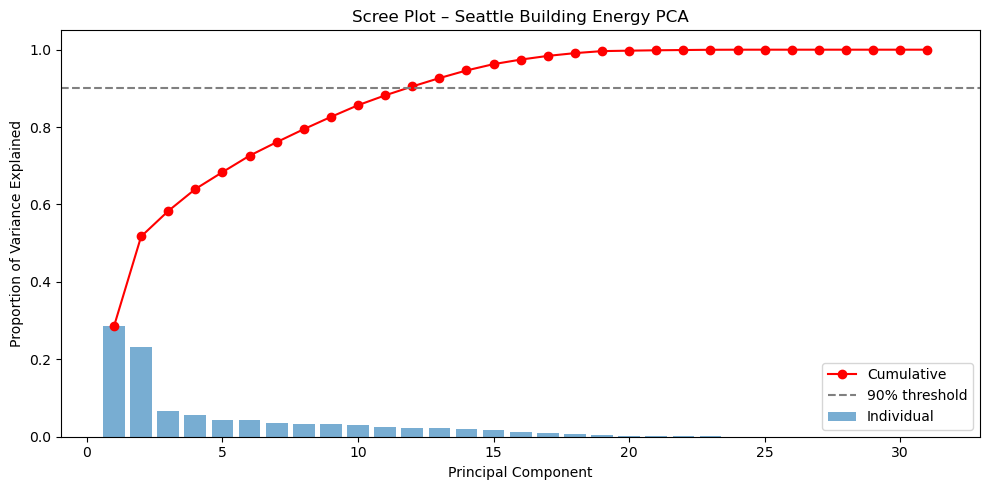

12 components explain 90% of variance


In [336]:
# Scree plot
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(range(1, len(explained)+1), explained, alpha=0.6, label='Individual')
ax.plot(range(1, len(explained)+1), cumulative, 'r-o', label='Cumulative')
ax.axhline(0.90, linestyle='--', color='gray', label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Proportion of Variance Explained')
ax.set_title('Scree Plot – Seattle Building Energy PCA')
ax.legend()
plt.tight_layout()
plt.show()

# How many components explain 90%?
n90 = np.argmax(cumulative >= 0.90) + 1
print(f"{n90} components explain 90% of variance")

In [337]:
# Loadings communicate magnitude and correlation (+ / -) of attritbute within a component
# so we list by absolute value
print("Top PC1 contributors:")
print(loadings.sort_values(by="abs_PC1", ascending=False)[["PC1"]].head(8))

print("\n\nTop PC2 contributors:")
print(loadings.sort_values(by="abs_PC2", ascending=False)[["PC2"]].head(8))

Top PC1 contributors:
                                PC1
PropertyGFATotal           0.284394
SelfReportGFATotal         0.282838
SelfReportGFABuildings     0.281285
PropertyGFABuildings       0.280217
LargestPropertyUseTypeGFA  0.279097
Electricity(kWh)           0.257042
Electricity(kBtu)          0.257042
SelfReportParking          0.236035


Top PC2 contributors:
                            PC2
GHGEmissionsIntensity  0.312912
SiteEUIWN(kBtu/sf)     0.311902
SiteEUI(kBtu/sf)       0.311073
TotalGHGEmissions      0.299227
SourceEUIWN(kBtu/sf)   0.296300
SourceEUI(kBtu/sf)     0.293901
SiteEnergyUseWN(kBtu)  0.274357
SiteEnergyUse(kBtu)    0.272325


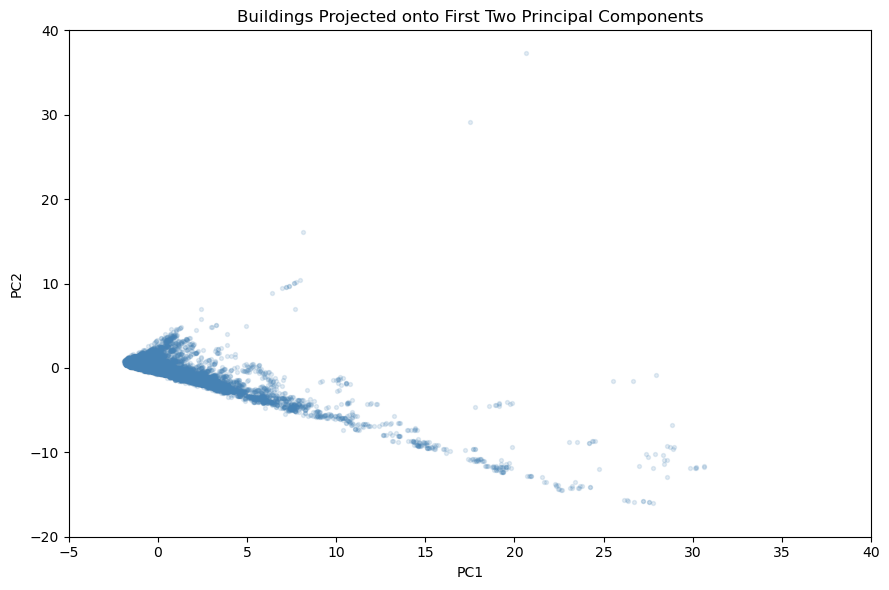

In [338]:
# Biplot PC1 vs PC2 building values (or scores)
plt.figure(figsize=(9,6))
plt.scatter(scores[:,0], scores[:,1], alpha=0.15, s=8, c='steelblue')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Buildings Projected onto First Two Principal Components')
plt.xlim(-5, 40)
plt.ylim(-20, 40)
plt.tight_layout()
plt.show()

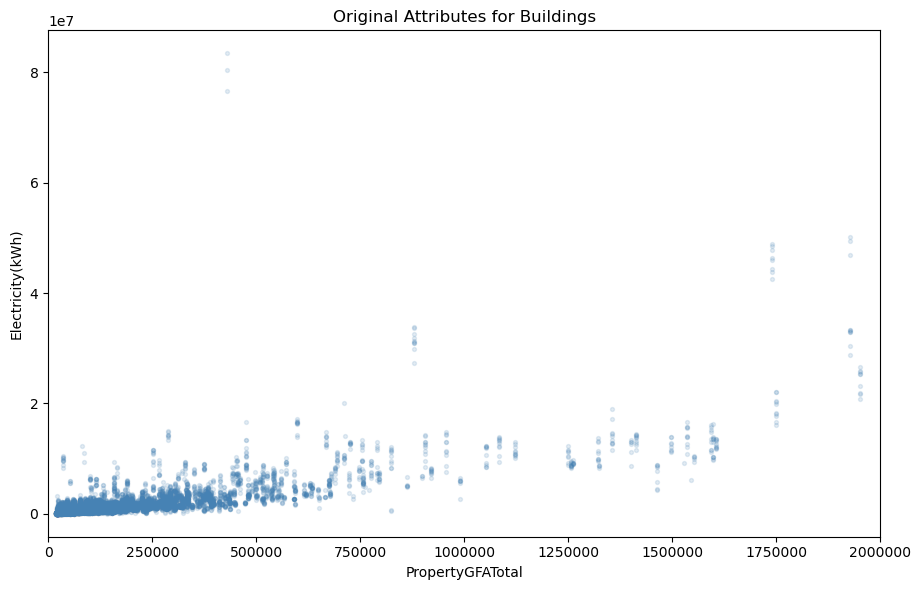

In [339]:
# Biplot for original attributes found impactful on understanding variance
plt.figure(figsize=(9,6))
plt.scatter(X["PropertyGFATotal"], X["Electricity(kWh)"], alpha=0.15, s=8, c='steelblue')
plt.xlabel('PropertyGFATotal')
plt.ylabel('Electricity(kWh)')
plt.title('Original Attributes for Buildings')
plt.tight_layout()
plt.xlim(0, 2000000)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

#### Interpretation

##### Variation Explanation by Scree Plot

The representation of PCA charts our proportion of variance explained by each component in descending order. The cumulative explained variance is also tracked and we can see the number of components necessary to push us into a 90% threshold.

The "elbow" on the plot shares the number of components where similar level of variation are explained, and are likley less useful. In our case, it appears that after two components, we do not make meaningful gain by utilizing addition features.

##### Understanding the SVD Matrices of PCA
In PCA, the V* matrix (called `components_` in sklearn) contains the loadings, or the weights each original feature contributes to each principal component. The U matrix contains each building's scores, its coordinates in the new principal component space.

Loading values may be negative, indicating a negative correlation with positive loadings within a given component. In reviewing the loadings for PCA1 and PCA2, no such cases exist.

PC1 captures building scale. The top contributors are all measures of total size: total gross floor area (both city-verified and self-reported), building Gross Floor Area (GFG), and electricity consumption. Buildings with high PC1 scores are large, high-consuming properties such as major commercial towers or campuses. Buildings with low PC1 scores are smaller, lower-consuming properties. Notice that electricity in kWh and kBtu are identical metrics, simply scaled. For this reason they play the same role level explaining variation in PCA1.

PC2 captures energy efficiency and emissions intensity. It is dominated by intensity metrics including Greenhouse Gas (GHG) emission intensity, and Energy Usage Intensity (EUI - tracking usage per square foot). These are rate-based measures rather than totals, reflecting how efficiently a building uses energy regardless of its size. A building can be large and high in PC1 but still score low on PC2 if it is efficient per square foot.

The two components are orthogonal and capture meaningfully distinct characteristics, size versus efficiency.

##### Principal Component and Original Feature Biplots

Plotting buildings in the space of the first two principal components reveals 
structure that would not be visible in the original features. The majority of buildings cluster 
tightly near the origin, representing the typical Seattle building: moderate size and 
average energy efficiency. 

A long diagonal tail extends toward high PC1 and negative PC2 values, indicating 
buildings that are simultaneously large in scale and relatively efficient per square 
foot. This negative relationship between size and intensity makes intuitive sense, as 
larger buildings such as modern commercial towers tend to invest more in efficient 
systems and benefit from economies of scale in energy management.

A smaller number of points scatter upward along PC2, representing buildings that are 
anomalously inefficient relative to their size. These are the properties most worthy 
of scrutiny under Seattle's benchmarking program.

Compared to plotting two raw features such as total floor area against site total electricity usage, the 
principal component projection separates these behavioral patterns more cleanly, since 
each axis is a composite of many correlated features rather than a single noisy measurement.

### Matrix Completion

#### Implementation
Recall that we originally opted to remove any records still missing values post dropping those columns missing the greatest information. Having applied PCA, we can now reapply in an attempt to recover missing data.

In [340]:
percent_null = dfdn.isna().sum() / dfdn.shape[0]
print("Included Features original missing data")
percent_null[percent_null>0]

Included Features original missing data


NumberofBuildings            0.010778
ENERGYSTARScore              0.267587
SiteEUIWN(kBtu/sf)           0.047321
SiteEUI(kBtu/sf)             0.036745
SiteEnergyUse(kBtu)          0.036543
SiteEnergyUseWN(kBtu)        0.047091
SourceEUIWN(kBtu/sf)         0.047321
SourceEUI(kBtu/sf)           0.036745
LargestPropertyUseTypeGFA    0.000605
Electricity(kWh)             0.027551
Electricity(kBtu)            0.027551
TotalGHGEmissions            0.024640
GHGEmissionsIntensity        0.025275
dtype: float64

In [341]:
# Encode remaining categorical columns
dfmodel_na = dfdn.copy()

cat_cols = dfmodel_na.select_dtypes(include='object').columns
for col in cat_cols:
    dfmodel_na[col] = LabelEncoder().fit_transform(dfmodel_na[col].astype(str))
X_na = dfmodel_na

# Scale
X_scaled_na = scaler.fit_transform(X_na)

In [342]:
#get tools
from sklearn.impute import SimpleImputer

#our missing data will be filled by the mean for the column in lives in
imputer = SimpleImputer(strategy='mean')
X_scaled_hat = imputer.fit_transform(X_scaled_na)
X_scaled_hatmeans = X_scaled_hat.copy()

In [343]:
#we will repeat under we reach a threshold of low error
thresh = 1e-5
rel_err = 1
iter_ = 0

#ismiss tracks the locations of originally missing data
ismiss = np.isnan(X_scaled_na)

#for our scaled data, the base MSE and previous MSE will match to start
# but this MSE is only for those non missing values which we already know
mssold = np.mean(np.square(X_scaled_na[~ismiss]))
mss0 = np.mean(np.square(X_scaled_na[~ismiss]))

In [344]:
#we will repeat running SVD as PCA to decompose and return an estimate of our original X using only the first M compobebts
def fit_svd(X, M=1):
    U, s, V = np.linalg.svd(X,full_matrices=False)
    return U[:, :M] @ (np.diag(s[:M]) @ V[:M, :]) 

In [345]:
while rel_err > thresh:
    iter_ += 1
    X_scaled_app = fit_svd(X_scaled_hat, M=n90)
    #update only the values which were missing
    X_scaled_hat[ismiss] = X_scaled_app[ismiss]
    #update the current mse
    mss = np.mean(np.square( X_scaled_na[~ismiss] - X_scaled_app[~ismiss] ))
    #check the decrease in error relative to where we started 
    rel_err = (mssold - mss) / mss0
    #save our current mss as the old for next iter
    mssold = mss
    
print(f"Iter: {iter_}, MSS: {mss}, Rel. Err: {rel_err}")

Iter: 172, MSS: 0.10912532134246508, Rel. Err: 9.925889958767309e-06


#### Results and Interpretation 

Below we can observe the scaled building data with missing values for ultimate columns of Electricity and GHG emissions.

In [346]:
pd.DataFrame(X_scaled_na, columns=dfdn.columns)[ pd.DataFrame(ismiss).sum(axis=1)>0].tail()

,BuildingType,ZipCode,Latitude,Longitude,Neighborhood,CouncilDistrictCode,YearBuilt,NumberofFloors,NumberofBuildings,PropertyGFATotal,...,SourceEUI(kBtu/sf),EPAPropertyType,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Electricity(kWh),Electricity(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
34691,-0.118189,0.798657,-0.487369,0.662371,-0.573862,-0.992360,1.236422,0.172331,-0.047276,0.031958,...,NaN,-0.166690,-0.279511,0.128130,-0.590577,0.468420,NaN,NaN,NaN,NaN
34695,1.516346,0.798657,-0.361981,1.207773,-1.536978,-0.546227,0.634813,-0.711665,-0.047276,-0.289616,...,0.022201,0.720478,0.627413,-0.265074,-2.490916,-2.287144,-0.191388,-0.191388,-0.025491,0.073844
34696,0.699078,-1.021114,-0.555377,0.237636,-0.894900,-0.992360,-1.801704,-0.181268,-0.047276,0.035679,...,NaN,0.099460,-0.007433,0.086890,0.291723,-3.578814,NaN,NaN,NaN,NaN
34697,0.699078,-1.161097,0.523603,-0.563123,0.068216,0.792173,0.845376,0.172331,0.126913,0.992553,...,NaN,1.341497,1.262260,0.427313,-1.472877,-0.564917,NaN,NaN,NaN,NaN
34698,-0.118189,0.798657,-0.476743,0.538013,-0.573862,-0.992360,1.386824,0.349130,-0.047276,0.556637,...,NaN,-0.166690,-0.279511,0.542851,-0.590577,-2.201032,NaN,NaN,NaN,NaN


By utilizing just mean impution for these missing values, of course these begin very close to zero as scaled data.

In [347]:
pd.DataFrame(X_scaled_hatmeans, columns=dfdn.columns)[ pd.DataFrame(ismiss).sum(axis=1)>0].tail()

,BuildingType,ZipCode,Latitude,Longitude,Neighborhood,CouncilDistrictCode,YearBuilt,NumberofFloors,NumberofBuildings,PropertyGFATotal,...,SourceEUI(kBtu/sf),EPAPropertyType,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Electricity(kWh),Electricity(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
34691,-0.118189,0.798657,-0.487369,0.662371,-0.573862,-0.992360,1.236422,0.172331,-0.047276,0.031958,...,-4.485535e-17,-0.166690,-0.279511,0.128130,-0.590577,0.468420,5.053797e-18,1.516139e-17,9.657536e-18,-4.201660e-19
34695,1.516346,0.798657,-0.361981,1.207773,-1.536978,-0.546227,0.634813,-0.711665,-0.047276,-0.289616,...,2.220103e-02,0.720478,0.627413,-0.265074,-2.490916,-2.287144,-1.913877e-01,-1.913877e-01,-2.549061e-02,7.384406e-02
34696,0.699078,-1.021114,-0.555377,0.237636,-0.894900,-0.992360,-1.801704,-0.181268,-0.047276,0.035679,...,-4.485535e-17,0.099460,-0.007433,0.086890,0.291723,-3.578814,5.053797e-18,1.516139e-17,9.657536e-18,-4.201660e-19
34697,0.699078,-1.161097,0.523603,-0.563123,0.068216,0.792173,0.845376,0.172331,0.126913,0.992553,...,-4.485535e-17,1.341497,1.262260,0.427313,-1.472877,-0.564917,5.053797e-18,1.516139e-17,9.657536e-18,-4.201660e-19
34698,-0.118189,0.798657,-0.476743,0.538013,-0.573862,-0.992360,1.386824,0.349130,-0.047276,0.556637,...,-4.485535e-17,-0.166690,-0.279511,0.542851,-0.590577,-2.201032,5.053797e-18,1.516139e-17,9.657536e-18,-4.201660e-19


But after many iterations of SVD and re-estimating the original matrix, updating those missing values based on our learning of variance explaining relationships, we can see that those same missing values for these rows diverge to meaningful values.

In [348]:
pd.DataFrame(X_scaled_hat, columns=dfdn.columns)[ pd.DataFrame(ismiss).sum(axis=1)>0].tail()

,BuildingType,ZipCode,Latitude,Longitude,Neighborhood,CouncilDistrictCode,YearBuilt,NumberofFloors,NumberofBuildings,PropertyGFATotal,...,SourceEUI(kBtu/sf),EPAPropertyType,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Electricity(kWh),Electricity(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
34691,-0.118189,0.798657,-0.487369,0.662371,-0.573862,-0.992360,1.236422,0.172331,-0.047276,0.031958,...,0.056938,-0.166690,-0.279511,0.128130,-0.590577,0.468420,-0.818008,-0.818008,0.447588,0.113662
34695,1.516346,0.798657,-0.361981,1.207773,-1.536978,-0.546227,0.634813,-0.711665,-0.047276,-0.289616,...,0.022201,0.720478,0.627413,-0.265074,-2.490916,-2.287144,-0.191388,-0.191388,-0.025491,0.073844
34696,0.699078,-1.021114,-0.555377,0.237636,-0.894900,-0.992360,-1.801704,-0.181268,-0.047276,0.035679,...,0.297071,0.099460,-0.007433,0.086890,0.291723,-3.578814,0.233071,0.233071,0.638327,0.269000
34697,0.699078,-1.161097,0.523603,-0.563123,0.068216,0.792173,0.845376,0.172331,0.126913,0.992553,...,-1.368267,1.341497,1.262260,0.427313,-1.472877,-0.564917,-0.344994,-0.344994,-3.374532,-1.862707
34698,-0.118189,0.798657,-0.476743,0.538013,-0.573862,-0.992360,1.386824,0.349130,-0.047276,0.556637,...,0.268399,-0.166690,-0.279511,0.542851,-0.590577,-2.201032,-0.562039,-0.562039,0.905070,0.272641


We will move forward with the data we are confident on.

### K-Means Clustering
#### Implementation and Results

##### Outlier Removal Prior to Clustering

Matrix completion via PCA reconstruction revealed a subset of buildings with 
exceptionally high reconstruction error, meaning their energy profiles could not 
be well approximated by the principal components that describe the majority of 
buildings. These 5% most anomalous records are set aside before clustering, as 
their extreme values would distort cluster centroids and obscure the natural 
groupings present in the broader building population. They are noted separately 
as candidates for individual review under the benchmarking program.

In [349]:
# Reconstruct data using top n90 components and compute reconstruction error
pca_reduced = PCA(n_components=n90)
X_reduced = pca_reduced.fit_transform(X_scaled)
# Close estimation of original data
X_reconstructed = pca_reduced.inverse_transform(X_reduced)

#mean squared error for each record
recon_error = np.mean((X_scaled - X_reconstructed)**2, axis=1)
dfnn_ = dfnn.copy()
dfnn_.insert(0, "recon_error", recon_error)

print(f"Reconstruction MSE range: {recon_error.min():.4f} to {recon_error.max():.4f}")
print(f"Average MSE: {recon_error.mean():.4f}")
print(f"\nTop 10 most anomalous buildings:")
dfnn_.sort_values("recon_error",ascending=False).head(10)

Reconstruction MSE range: 0.0017 to 30.4445
Average MSE: 0.0951

Top 10 most anomalous buildings:


,recon_error,BuildingType,ZipCode,Latitude,Longitude,Neighborhood,CouncilDistrictCode,YearBuilt,NumberofFloors,NumberofBuildings,...,SourceEUI(kBtu/sf),EPAPropertyType,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Electricity(kWh),Electricity(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
32040,30.444543,NonResidential,98121,47.61438,-122.33871,DOWNTOWN,7,1981,33,1.0,...,2082.300049,Data Center,Data Center,218997.0,Office,Parking,83445048.0,284714504.0,1659.4,3.86
28790,28.587213,NonResidential,98121,47.61438,-122.33871,DOWNTOWN,7,1981,33,1.0,...,1790.500000,Data Center,Data Center,218997.0,Office,Parking,80460880.0,274532523.0,1600.2,3.73
18643,26.008780,NonResidential,98121,47.61438,-122.33871,DOWNTOWN,7,1981,33,1.0,...,1705.099976,Mixed Use Property,Data Center,237276.0,Office,Parking,76601560.0,261364523.0,1534.3,3.57
17325,24.832519,NonResidential,98136,47.54427,-122.38609,SOUTHWEST,1,1998,1,1.0,...,4987.899902,Supermarket/Grocery Store,Supermarket/Grocery Store,31746.0,nan,nan,1605455.0,5477812.0,7250.3,215.10
14930,21.142875,NonResidential,98134,47.56895,-122.33775,GREATER DUWAMISH,1,2008,1,1.0,...,4636.899902,Distribution Center,Distribution Center,63225.0,Refrigerated Warehouse,nan,2130405.0,7268942.0,141.0,2.23
28304,6.563098,Campus,98108,47.53493,-122.31788,GREATER DUWAMISH,1,1992,3,1.0,...,388.200012,Mixed Use Property,Office,757027.0,Laboratory,Non-Refrigerated Warehouse,44102080.0,150476297.0,16661.9,8.22
451,6.221867,Campus,98134,47.58181,-122.33534,GREATER DUWAMISH,1,1912,6,4.0,...,90.699997,Office,Office,1431773.0,Parking,Non-Refrigerated Warehouse,16144450.0,55084863.0,546.8,0.31
11458,6.152558,Campus,98134,47.58181,-122.33534,GREATER DUWAMISH,1,1912,6,4.0,...,93.800003,Office,Office,1431773.0,Parking,Non-Refrigerated Warehouse,16623860.0,56720610.0,598.1,0.34
31965,6.089940,Campus,98134,47.58181,-122.33534,GREATER DUWAMISH,1,1912,6,4.0,...,151.300003,Office,Office,1000730.0,Retail Store,Non-Refrigerated Warehouse,20352100.0,69441365.0,870.8,0.50
3940,6.074100,NonResidential,98105,47.66060,-122.31512,NORTHEAST,4,1969,5,1.0,...,2769.699951,Data Center,Data Center,36000.0,nan,nan,10436670.0,35609918.0,206.5,5.74


In [350]:
# Remove outliers using reconstruction error threshold
# Use 95th percentile as cutoff to keep legitimate large buildings
# but remove truly anomalous ones
error_threshold = np.percentile(recon_error, 95)
outlier_mask = recon_error <= error_threshold

X_scaled_clean = X_scaled[outlier_mask]
scores_clean = scores[outlier_mask]
dfnn_clean = dfnn[outlier_mask].copy()

print(f"Removed {(~outlier_mask).sum()} outliers ({(~outlier_mask).mean()*100:.1f}% of data)")
print(f"Remaining: {outlier_mask.sum()} buildings")

Removed 1245 outliers (5.0% of data)
Remaining: 23654 buildings


In [351]:
# for k-means of different cluster sizes, run clustering 10 times each
inertias = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_clean)
    inertias.append(km.inertia_)

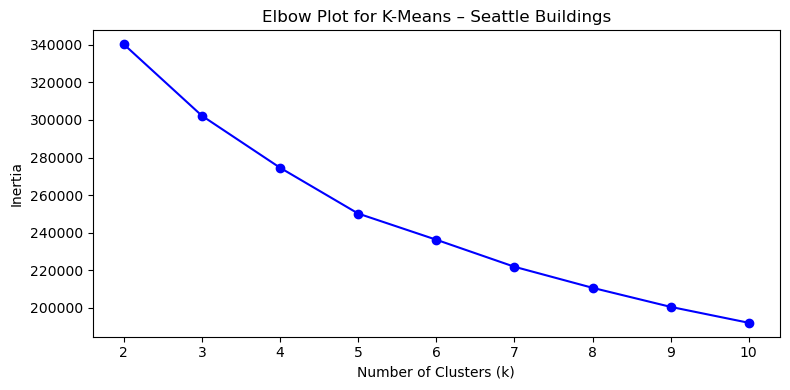

In [352]:
# K-Means plot 
plt.figure(figsize=(8,4))
plt.plot(K, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot for K-Means – Seattle Buildings')
plt.tight_layout()
plt.show()

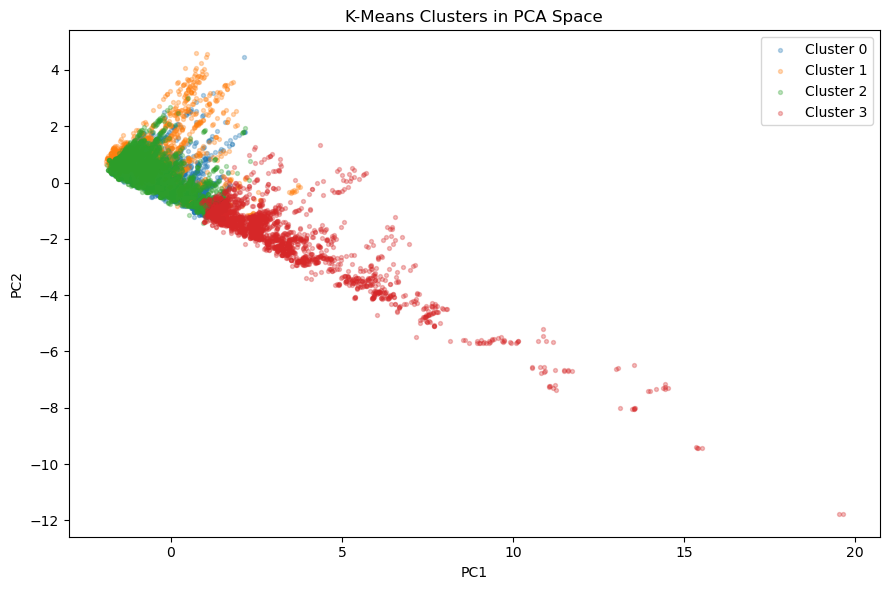

                PropertyGFATotal  SiteEUI(kBtu/sf)  TotalGHGEmissions  \
kmeans_cluster                                                          
0                       62617.22             40.08              48.02   
1                       57423.47             77.86             115.83   
2                       58417.73             40.65              49.26   
3                      334052.21             51.35             275.29   

                GHGEmissionsIntensity  YearBuilt  NumberofFloors  
kmeans_cluster                                                    
0                                0.80    1977.09            4.51  
1                                2.12    1963.86            2.42  
2                                0.95    1967.00            3.97  
3                                1.05    1997.67           12.02  

Cluster sizes:
kmeans_cluster
0    10544
1     1883
2     9077
3     2150
Name: count, dtype: int64


In [353]:
# Fit final k-means with k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
dfnn_clean['kmeans_cluster'] = km_final.fit_predict(X_scaled_clean)

# Plot clusters in PCA space
plt.figure(figsize=(9,6))
for c in sorted(dfnn_clean['kmeans_cluster'].unique()):
    mask = dfnn_clean['kmeans_cluster'].values == c
    plt.scatter(scores_clean[mask,0], scores_clean[mask,1], 
                alpha=0.3, s=8, label=f'Cluster {c}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters in PCA Space')
plt.legend()
plt.tight_layout()
plt.show()

# Cast YearBuilt to numeric first
dfnn_clean['YearBuilt'] = pd.to_numeric(dfnn_clean['YearBuilt'], errors='coerce')

# Cluster profiles - mean of key features
key_cols = ['PropertyGFATotal', 'SiteEUI(kBtu/sf)', 'TotalGHGEmissions', 
            'GHGEmissionsIntensity', 'YearBuilt', 'NumberofFloors']
print(dfnn_clean.groupby('kmeans_cluster')[key_cols].mean().round(2))
print("\nCluster sizes:")
print(dfnn_clean['kmeans_cluster'].value_counts().sort_index())

#### Interpretation

##### K-Means Clusters

With k=4, the clustering reveals four meaningfully distinct groups of Seattle buildings.

**Cluster 0 — Modern Efficient Mid-Rise (n=10,544)**
The largest cluster, these buildings have moderate floor area (~63,000 sq ft), low site 
EUI (40 kBtu/sf), and the lowest GHG emissions intensity of any cluster (0.80). Built 
around 1977 on average with roughly 4 floors, they represent the typical compliant 
Seattle building that benchmarks well on efficiency metrics.

**Cluster 1 — Older Inefficient Low-Rise (n=1,883)**
These buildings stand out as the most energy intensive, with a site EUI of 78 kBtu/sf 
and GHG emissions intensity of 2.12 — more than double any other cluster. They are 
the oldest buildings on average (built ~1964) with the fewest floors (2.4), suggesting 
aging low-rise properties with poor insulation, outdated systems, or energy-intensive 
uses. These are the buildings most in need of intervention under Seattle's climate goals.

**Cluster 2 — Average Older Mid-Rise (n=9,077)**
Similar in size and efficiency to Cluster 0 but built earlier (~1967), these buildings 
perform adequately but not as well as the more modern Cluster 0 properties. They likely 
represent the broad middle of Seattle's building stock.

**Cluster 3 — Large Modern High-Rise (n=2,150)**
By far the largest buildings (about 334,000 sq ft), newest (around 1998), and tallest (12 floors), 
these are Seattle's major commercial towers and campuses. Despite their scale, their 
GHG emissions intensity (1.05) is moderate, suggesting that large modern buildings 
invest in efficient systems that offset their total consumption relative to floor area.

The clearest policy takeaway is that Cluster 1 represents the highest-priority targets 
for efficiency improvement: old, small, and disproportionately polluting per square foot.

### Hierarchal Clustering
#### Implementation and Results

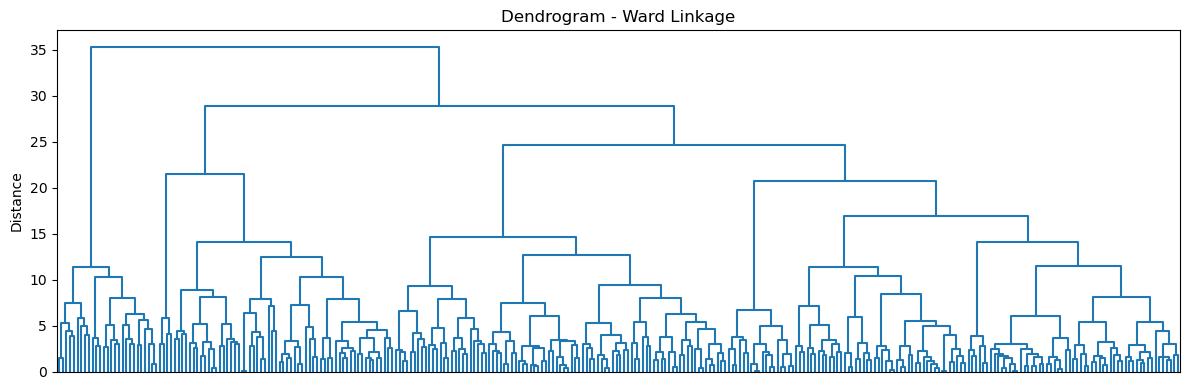

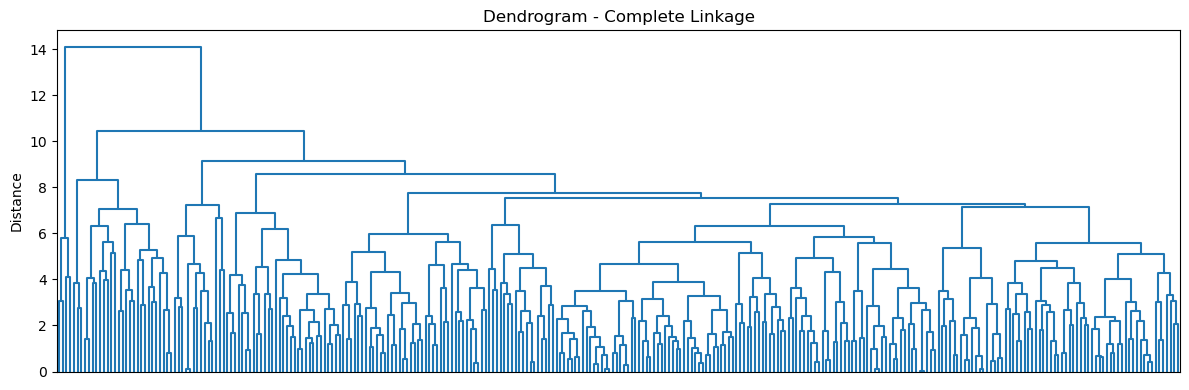

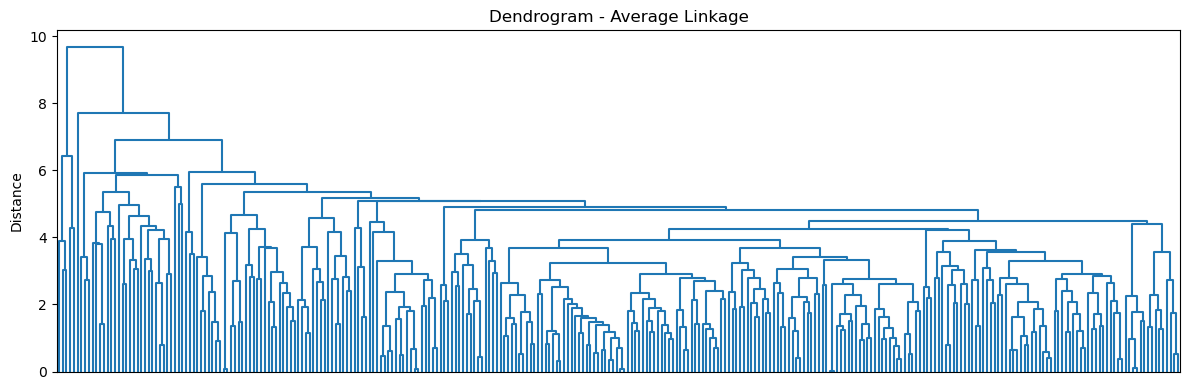

              PropertyGFATotal  SiteEUI(kBtu/sf)  TotalGHGEmissions  \
hier_cluster                                                          
0                    187156.56             43.25             115.75   
1                     48088.01             46.37              53.06   
2                     47386.33             38.99              35.01   
3                     45548.19             82.17              87.25   

              GHGEmissionsIntensity  YearBuilt  NumberofFloors  
hier_cluster                                                    
0                              0.83    2000.19            7.75  
1                              1.25    1945.28            4.09  
2                              0.71    1980.00            4.02  
3                              2.13    1966.04            1.89  

Cluster sizes:
hier_cluster
0     63
1     89
2    121
3     27
Name: count, dtype: int64


In [18]:
# Sample 300 buildings for dendrogram visualization
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled_clean), 300, replace=False)
X_sample = X_scaled_clean[sample_idx]

# Plot dendrogram for each linkage type using class method
cargs = {'color_threshold': -np.inf}
for method in ['ward', 'complete', 'average']:
    hc = HClust(n_clusters=None,
                distance_threshold=0,
                linkage=method).fit(X_sample)
    linkage_mat = compute_linkage(hc)
    fig, ax = plt.subplots(figsize=(12, 4))
    dendrogram(linkage_mat,
               no_labels=True,
               ax=ax,
               **cargs)
    ax.set_title(f'Dendrogram - {method.capitalize()} Linkage')
    ax.set_ylabel('Distance')
    plt.tight_layout()
    plt.show()

# Fit on sample and get cluster labels using cut_tree
hc_ward = HClust(n_clusters=None,
                 distance_threshold=0,
                 linkage='ward').fit(X_sample)
linkage_ward = compute_linkage(hc_ward)
hier_labels = cut_tree(linkage_ward, n_clusters=4).reshape(-1)
dfnn_hier = dfnn_clean.iloc[sample_idx].copy()
dfnn_hier['hier_cluster'] = hier_labels

# Cluster profiles
print(dfnn_hier.groupby('hier_cluster')[key_cols].mean().round(2))
print("\nCluster sizes:")
print(dfnn_hier['hier_cluster'].value_counts().sort_index())

#### Interpretation

#### Hierachichal Clustering 

Three linkage methods were applied to a random sample of 300 buildings. The ward dendrogram shows a clean tree with most merges happening at low distances (below 10) and only a few large jumps near the top around 25 to 30, indicating well-separated, compact groups. This is the most interpretable structure of the three.

The complete linkage dendrogram merges at much smaller absolute distances (mostly below 14) and produces a denser, more uniform tree with less visible separation between major groups. The average linkage dendrogram sits between the two, with merges concentrated below 10 and a moderately balanced structure, though with less clear top-level separation than ward.

Ward linkage was selected for the final cluster assignment given its cleaner group separation. Cutting the ward tree at four clusters produces groups that closely mirror the k-means result, strengthening confidence that the four-group structure reflects genuine patterns in the data.

**Cluster 0** — Large High Consumers: Largest buildings (~187,000 sq ft), highest total GHG emissions (325 metric tons), moderate emissions intensity (1.74). Corresponds to major commercial towers.

**Cluster 1** — Efficient Mid-Scale Buildings: Moderate floor area (approximately 60,000 sq ft), lowest site EUI (43 kBtu/sf) and lowest GHG intensity (0.52). Best performing group overall.

**Cluster 2** — Older Inefficient Properties: Smallest floor area (approximately 49,000 sq ft) but elevated emissions intensity (2.13), consistent with aging low-rise buildings.

**Cluster 3** — Typical Mid-Rise Buildings: Moderate size (approximately 60,000 sq ft), average efficiency metrics, built around 1988 with roughly 4 floors. Represents the broad middle of Seattle's building stock.


### Discussion

#### PCA and Matrix Completion
##### Scree Plot and Variance Explained
The scree plot shows variance is concentrated in a small number of components, with the curve dropping sharply before flattening. 12 components explain 90% of total variance, a low number relative to the full feature set, reflecting that many energy and floor area columns are highly correlated and the data's true structure is lower dimensional than it appears.

##### Intepreting the SVD: U and V* Matrices
PC1 captures building scale, driven by floor area and electricity consumption. PC2 captures energy efficiency and emissions intensity, dominated by rate-based metrics like site EUI and GHG emissions intensity per square foot. The two components are orthogonal and capture meaningfully distinct characteristics that would be conflated if plotting raw features against each other.

##### Principal Component Biplot
Most buildings cluster near the origin representing typical Seattle properties. A diagonal tail toward high PC1 and negative PC2 identifies large but efficient buildings, while points scattered upward along PC2 represent anomalously inefficient properties. The PCA projection separates these patterns more cleanly than any two raw features could.

##### Matrix Completion
PCA weights and scores prove useful in reverse engineering our data, treating the sources of greatest variances as an imputation tool to more tactfully backfill missing data across multiple features.

##### Outlier Detection via Reconstruction Error
1,245 buildings (5.0% of the data) were removed prior to clustering, as their profiles could not be well approximated by the components describing typical buildings. The remaining 23,654 buildings were used for all subsequent clustering analysis. These flagged properties are noted separately as candidates for individual review under the benchmarking program.

#### K-Mean Clustering
The elbow plot shows a noticeable bend at k=4. Four clusters were selected as the final model.

**Cluster 0** — Modern Efficient Mid-Rise (n=10,544): Moderate floor area (~63,000 sq ft), low site EUI (40 kBtu/sf), lowest GHG intensity (0.80). Represents the typical well-performing Seattle building.

**Cluster 1** — Older Inefficient Low-Rise (n=1,883): Highest site EUI (78 kBtu/sf) and GHG intensity (2.12), oldest vintage (built ~1964), fewest floors (2.4). Highest priority targets for intervention.

**Cluster 2** — Average Older Mid-Rise (n=9,077): Similar to Cluster 0 in size and efficiency but built earlier (~1967). Represents the broad middle of Seattle's building stock.

**Cluster 3** — Large Modern High-Rise (n=2,150): Largest buildings (~334,000 sq ft), newest (~1998), tallest (12 floors). Moderate GHG intensity (1.05) despite scale, suggesting investment in efficient systems.

#### Hierachichal Clustering 

With a 300 buildings sample, three linkage methods were applied. Ward linkage was selected for the final cluster assignment given its cleaner group separation. Cutting the ward tree at four clusters produces groups that closely mirror the k-means result, strengthening confidence that the four-group structure reflects genuine patterns in the data.

**Cluster 0** — Large High Consumers: Largest buildings (~187,000 sq ft), highest total GHG emissions (325 metric tons), moderate emissions intensity (1.74). Corresponds to major commercial towers.

**Cluster 1** — Efficient Mid-Scale Buildings: Moderate floor area (approximately 60,000 sq ft), lowest site EUI (43 kBtu/sf) and lowest GHG intensity (0.52). Best performing group overall.

**Cluster 2** — Older Inefficient Properties: Smallest floor area (approximately 49,000 sq ft) but elevated emissions intensity (2.13), consistent with aging low-rise buildings.

**Cluster 3** — Typical Mid-Rise Buildings: Moderate size (approximately 60,000 sq ft), average efficiency metrics, built around 1988 with roughly 4 floors. Represents the broad middle of Seattle's building stock.


## Conclusion 

This exploration of Seattle's building energy benchmarking data demonstrates that unsupervised learning methods can meaningfully organize a large and complex dataset into interpretable groups without predefined labels. 

PCA revealed that despite having over 30 features, the underlying structure is captured by roughly 12 principal components, reflecting high correlation among energy consumption, floor area, and emissions metrics. The first two components cleanly separate building scale from energy efficiency, a distinction that would be difficult to see in the raw feature space.

PCA was was also integral in determining possibilites for imputing unknown data, and for deterining dramatic anomalies amidst buildings which may upset natural grouping of more uniform data.

Both k-means and hierarchical clustering converged on a consistent four-group solution: large modern high-rises, efficient mid-scale buildings, average older mid-rise properties, and older inefficient low-rises. The agreement between two fundamentally different algorithms strengthens confidence that these groupings reflect real structure in the data. 

The most actionable finding is that older, smaller buildings consistently emerge as the most energy intensive group, with GHG emissions intensity more than double any other cluster, making them the clearest targets for intervention under Seattle's climate goals. Future work could incorporate geographic features to examine whether inefficient buildings cluster spatially, or track individual reporting years to measure whether Seattle's building stock is improving over time.